# OMI Residential Real Estate Quotations: An Exploratory & Trend Analysis
---

## Executive Summary

This notebook provides a comprehensive, statistically grounded exploration of the semiannual **OMI (Osservatorio del Mercato Immobiliare)** real estate quotations published by the Italian *Agenzia delle Entrate*.

The analysis moves from a high-level national overview to increasingly granular geographical levels—regional, provincial, municipal, and intra-municipal ("zone")—with a dedicated focus on the Lombardy region and the Province of Brescia.

**Key Objectives:**
- To characterize the distribution and trends of residential purchase quotations (`Compr_mid`).
- To identify and rank the most and least expensive markets at different geographical levels.
- To analyze price dynamics over time, highlighting growth patterns and volatility.
- To provide a reproducible and extensible analytical framework for real estate data.

**Scope:** Residential purchase ("compravendita") quotations, expressed in €/m² as the midpoint of the OMI minimum/maximum range (`Compr_mid`).

---

## Table of Contents

1.  **Setup & Configuration**
2.  **Data Loading & Initial Inspection**
3.  **Property Type Overview**
4.  **Residential Subset Construction & Cleaning**
5.  **National Price Trend Analysis**
6.  **Regional Price Dynamics**
7.  **Provincial Market Analysis**
8.  **Municipal & Sub-Municipal Analysis**
9.  **Regional Deep Dive: Lombardy & Brescia**
10. **Growth & Risk Analytics**

> **Methodological Note:** Rankings based on growth rates (CAGR, volatility, drawdown) are restricted to series with a minimum amount of history (`MIN_PERIODS`) to ensure statistical significance. Series with insufficient data are excluded to avoid misleading conclusions from extreme, noisy growth figures.

## 1. Setup & Configuration

The analytical stack is kept lightweight: `pandas` for data preparation, `numpy` for numerical transformations, and `matplotlib`/`seaborn` for visualization. The project root is resolved relative to the notebook's working directory.

We define key analysis constants at the top, such as the minimum number of observations required for a market to be included in rankings and the minimum number of periods for growth calculations. This ensures methodological consistency throughout the notebook.

In [2]:
# Cell 1: Imports and Configuration
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set a professional plotting style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Resolve project root
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'quotations'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

# Analysis constants
MIN_OBSERVATIONS_FOR_RANKING = 20 # Minimum observations in the latest semester for a municipality/province to be included in rankings
MIN_PERIODS_FOR_GROWTH = 8        # Minimum number of semesters of data to calculate reliable growth metrics

## 2. Data Loading & Initial Inspection

Each semiannual OMI release is originally distributed as one semicolon-separated CSV per semester. Consolidating the individual raw releases into a single, typed, analysis-ready table—with an explicit `reference_date` attached to every semester—is handled upstream by the ingestion pipeline and persisted as a Parquet file.

This notebook loads the already-consolidated dataset directly.

In [3]:
# Cell 2: Load the pre-processed Parquet dataset
omi = pd.read_parquet(PROCESSED_DIR / "omi_quotations.parquet")

print(f"Dataset successfully loaded.")
print(f"Rows: {omi.shape[0]:,}")
print(f"Columns: {omi.shape[1]}")
display(omi.head())

Dataset successfully loaded.
Rows: 7,516,495
Columns: 36


,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,...,flag_negative_compr,flag_negative_loc,flag_invalid_semester,reference_date,Compr_mid,Loc_mid,Compr_spread,Loc_spread,Compr_spread_pct,Loc_spread_pct
0,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,False,False,False,2004-06-30,395.0,NaN,150.0,NaN,37.974684,NaN
1,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,False,False,False,2004-06-30,325.0,NaN,130.0,NaN,40.000000,NaN
2,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,False,False,False,2004-06-30,325.0,NaN,130.0,NaN,40.000000,NaN
3,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,False,False,False,2004-06-30,210.0,NaN,80.0,NaN,38.095238,NaN
4,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,False,False,False,2004-06-30,85.0,NaN,30.0,NaN,35.294118,NaN


### 2.1 Schema and Data Types

We first inspect the schema, data types, and memory usage of the raw table.

In [4]:
# Cell 3: Dataframe Information
omi.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 7516495 entries, 0 to 7516494
Data columns (total 36 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Area_territoriale      7516495 non-null  str           
 1   Regione                7516495 non-null  str           
 2   Prov                   7362317 non-null  str           
 3   Comune_ISTAT           7516458 non-null  float64       
 4   Comune_cat             7516495 non-null  str           
 5   Sez                    3491 non-null     str           
 6   Comune_amm             7516495 non-null  str           
 7   Comune_descrizione     7516495 non-null  str           
 8   Fascia                 7516495 non-null  str           
 9   Zona                   7516495 non-null  str           
 10  LinkZona               7516495 non-null  str           
 11  Cod_Tip                7516495 non-null  int64         
 12  Descr_Tipologia        7516495 non-null

### 2.2 Missing Value Analysis

We quantify the percentage of missing values for each column. High missing rates in key columns like `Compr_min` and `Compr_max` would require a specific imputation or filtering strategy.

In [5]:
# Cell 4: Missing values analysis
missing_share = (
    omi.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_share = missing_share[missing_share > 0]

if missing_share.empty:
    print("No missing values detected in any column.")
else:
    print("Columns with missing values (% of total):")
    display(missing_share.to_frame('missing_%').style.format('{:.2f}%').background_gradient(cmap='Reds'))

Columns with missing values (% of total):


,missing_%
Sez,99.95%
Loc_spread,95.68%
Loc_mid,95.68%
Loc_spread_pct,95.68%
Loc_max,85.99%
Loc_min,85.87%
Stato_prev,9.66%
Sup_NL_loc,7.48%
Prov,2.05%
Stato,1.28%


### 2.3 Temporal and Categorical Coverage

We check the time span of the data and the number of unique geographical entities. This confirms the scale and scope of our analysis.

In [6]:
# Cell 5: Temporal and Categorical Coverage
print(f"Reference period range: {omi['reference_date'].min().date()} → {omi['reference_date'].max().date()}")
print(f"Number of semesters covered: {omi['reference_date'].nunique()}")
print(f"Regions: {omi['Regione'].nunique()}")
print(f"Provinces: {omi['Prov'].nunique()}")
print(f"Municipalities: {omi['Comune_descrizione'].nunique()}")

Reference period range: 2004-06-30 → 2025-12-31
Number of semesters covered: 44
Regions: 20
Provinces: 102
Municipalities: 8220


## 3. Property Type Overview

The `Descr_Tipologia` column classifies observations by property type. We first examine the distribution of all typologies to confirm that our subsequent focus on residential properties is analytically sound. The residential segment (e.g., "Abitazioni", "Ville") is expected to be the most represented.

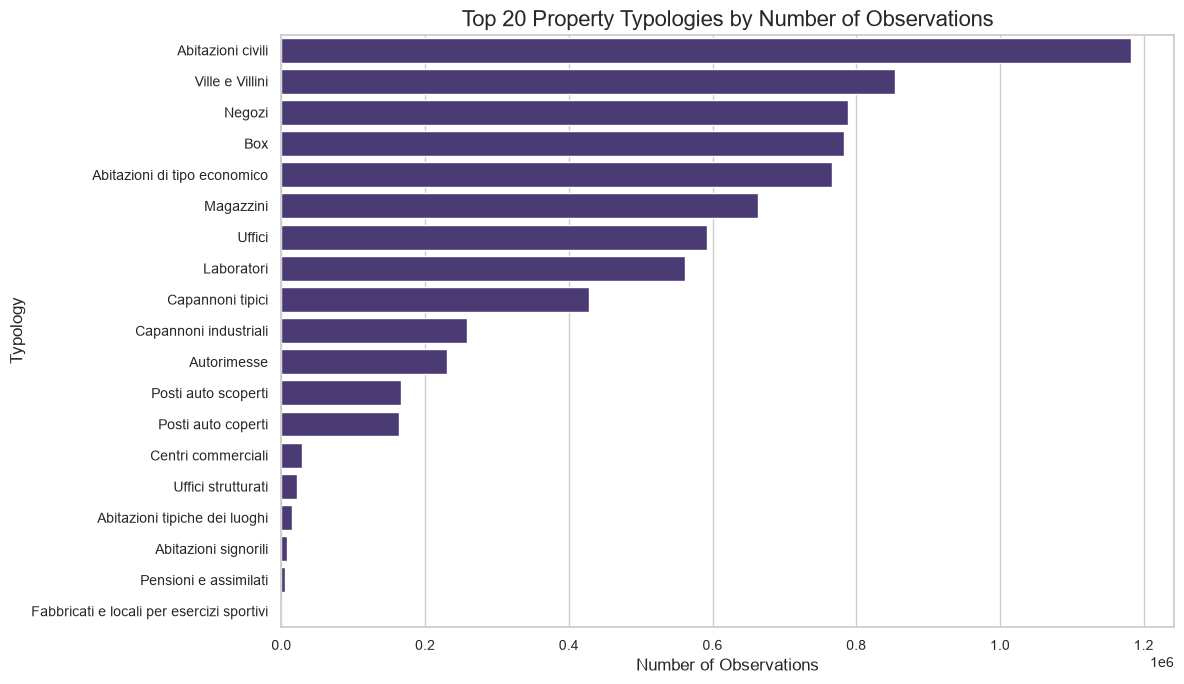

In [7]:
# Cell 6: Property Typology Distribution
fig, ax = plt.subplots(figsize=(12, 7))

typology_counts = omi['Descr_Tipologia'].value_counts().head(20)
sns.barplot(y=typology_counts.index, x=typology_counts.values, ax=ax, orient='h')

ax.set_title('Top 20 Property Typologies by Number of Observations')
ax.set_xlabel('Number of Observations')
ax.set_ylabel('Typology')
plt.tight_layout()
plt.show()

> **Insight:** The chart confirms that residential typologies represent a significant portion of the OMI dataset, justifying our focus. The presence of non-residential types (e.g., "Negozi", "Uffici") confirms the need for a filtering step.

## 4. Residential Subset Construction & Cleaning

The core of our analysis will focus on the residential segment. We construct this subset using a case-insensitive filter on the `Descr_Tipologia` column for Italian terms associated with residential properties: `abitazion` (covering various types of apartments) and `villa` (covering villas and similar properties).

We then validate the filter's output and standardize the `Compr_mid` column for analysis.

In [8]:
# Cell 7: Filter and validate residential properties
residential_mask = omi['Descr_Tipologia'].astype('string').str.contains(
    'abitazion|villa', case=False, na=False
)

print("Typologies captured by the residential filter:")
display(omi.loc[residential_mask, 'Descr_Tipologia'].value_counts())

residential = omi.loc[residential_mask].copy()
print(f"\nNumber of residential observations: {len(residential):,} ({len(residential) / len(omi):.1%} of the total)")

Typologies captured by the residential filter:


Descr_Tipologia
Abitazioni civili                1183089
Abitazioni di tipo economico      765963
Abitazioni tipiche dei luoghi      14287
Abitazioni signorili                8355
Name: count, dtype: int64


Number of residential observations: 1,971,694 (26.2% of the total)


### 4.1 Data Quality Checks

We check for and remove any invalid entries, such as negative prices or prices where the minimum is greater than the maximum.

In [9]:
# Cell 8: Data quality checks and cleaning
initial_rows = len(residential)

# Use flags created during ingestion
invalid_compr_mask = (
    residential['flag_negative_compr'] |
    residential['flag_compr_min_gt_max']
)
invalid_obs = invalid_compr_mask.sum()

print(f"Number of invalid residential observations (negative price or min > max): {invalid_obs}")

# Remove invalid rows
residential = residential[~invalid_compr_mask].copy()

final_rows = len(residential)
print(f"Removed {initial_rows - final_rows:,} rows. Final residential dataset has {final_rows:,} observations.")

# Also, drop rows where Compr_mid is NaN
residential.dropna(subset=['Compr_mid'], inplace=True)
print(f"Final residential dataset with valid 'Compr_mid': {len(residential):,} observations.")

Number of invalid residential observations (negative price or min > max): 0
Removed 0 rows. Final residential dataset has 1,971,694 observations.
Final residential dataset with valid 'Compr_mid': 1,964,835 observations.


## 5. National Price Trend Analysis

We begin our trend analysis by calculating the national median `Compr_mid` over time. Using the median provides a more robust measure of central tendency than the mean, as it is less affected by high-value outliers in a few premium markets. The mean is included for comparison.

In [10]:
# Cell 9: National trend calculation
national_trend = (
    residential
    .groupby('reference_date', as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

print("National trend (latest 10 semesters):")
display(national_trend.tail(10))

National trend (latest 10 semesters):


,reference_date,median_compr_mid,mean_compr_mid,observations
34,2021-06-30,900.0,1087.043634,44323
35,2021-12-31,900.0,1084.901347,44550
36,2022-06-30,895.0,1086.832873,44568
37,2022-12-31,895.0,1091.734147,44581
38,2023-06-30,895.0,1096.249776,44622
39,2023-12-31,895.0,1099.863701,44663
40,2024-06-30,890.0,1102.279793,44583
41,2024-12-31,890.0,1107.890620,44327
42,2025-06-30,900.0,1115.333657,44342
43,2025-12-31,900.0,1124.300717,44349


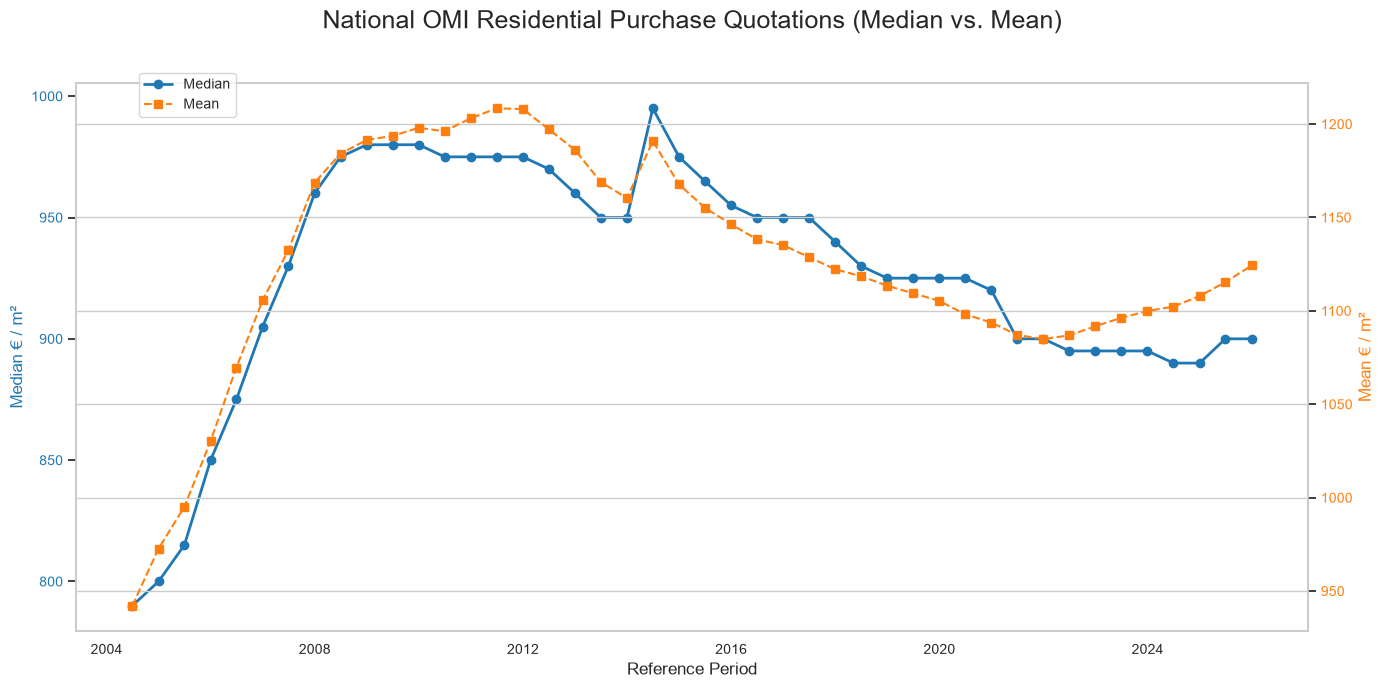

In [11]:
# Cell 10: Plot national trend
fig, ax1 = plt.subplots(figsize=(14, 7))

color_median = 'tab:blue'
color_mean = 'tab:orange'

ax1.set_xlabel('Reference Period')
ax1.set_ylabel('Median € / m²', color=color_median)
ax1.plot(national_trend['reference_date'], national_trend['median_compr_mid'], marker='o', linewidth=2, label='Median', color=color_median)
ax1.tick_params(axis='y', labelcolor=color_median)
ax1.grid(False)

ax2 = ax1.twinx()
ax2.set_ylabel('Mean € / m²', color=color_mean)
ax2.plot(national_trend['reference_date'], national_trend['mean_compr_mid'], marker='s', linestyle='--', linewidth=1.5, label='Mean', color=color_mean)
ax2.tick_params(axis='y', labelcolor=color_mean)

fig.suptitle('National OMI Residential Purchase Quotations (Median vs. Mean)', fontsize=18)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

> **Insight:** The national median quotation is relatively stable, hovering around 900 €/m² in recent years. However, the mean is significantly higher and shows a more pronounced upward trend. This divergence highlights the right-skewness of the market: a small number of very high-value municipalities (e.g., in major cities or luxury tourist destinations) pull the mean up, while the typical (median) quotation is much lower. This confirms our decision to use the median for analyzing broad trends.

## 6. Regional Price Dynamics

Moving to a more granular level, we analyze price levels and trends across Italy's 20 regions. We first rank regions by their median quotation in the most recent semester, then visualize their historical performance.

In [12]:
# Cell 11: Calculate regional trends
regional_trend = (
    residential
    .groupby(['reference_date', 'Regione'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)
latest_date = regional_trend['reference_date'].max()
print(f"Latest reference date: {latest_date.date()}")

Latest reference date: 2025-12-31


### 6.1 Top and Bottom 10 Regions

C:\Users\cc1323\AppData\Local\Temp\ipykernel_22124\400581302.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Regione', x='median_compr_mid', data=top_regions_latest.sort_values('median_compr_mid'), ax=ax1, palette='viridis')
C:\Users\cc1323\AppData\Local\Temp\ipykernel_22124\400581302.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Regione', x='median_compr_mid', data=bottom_regions_latest.sort_values('median_compr_mid', ascending=False), ax=ax2, palette='magma')


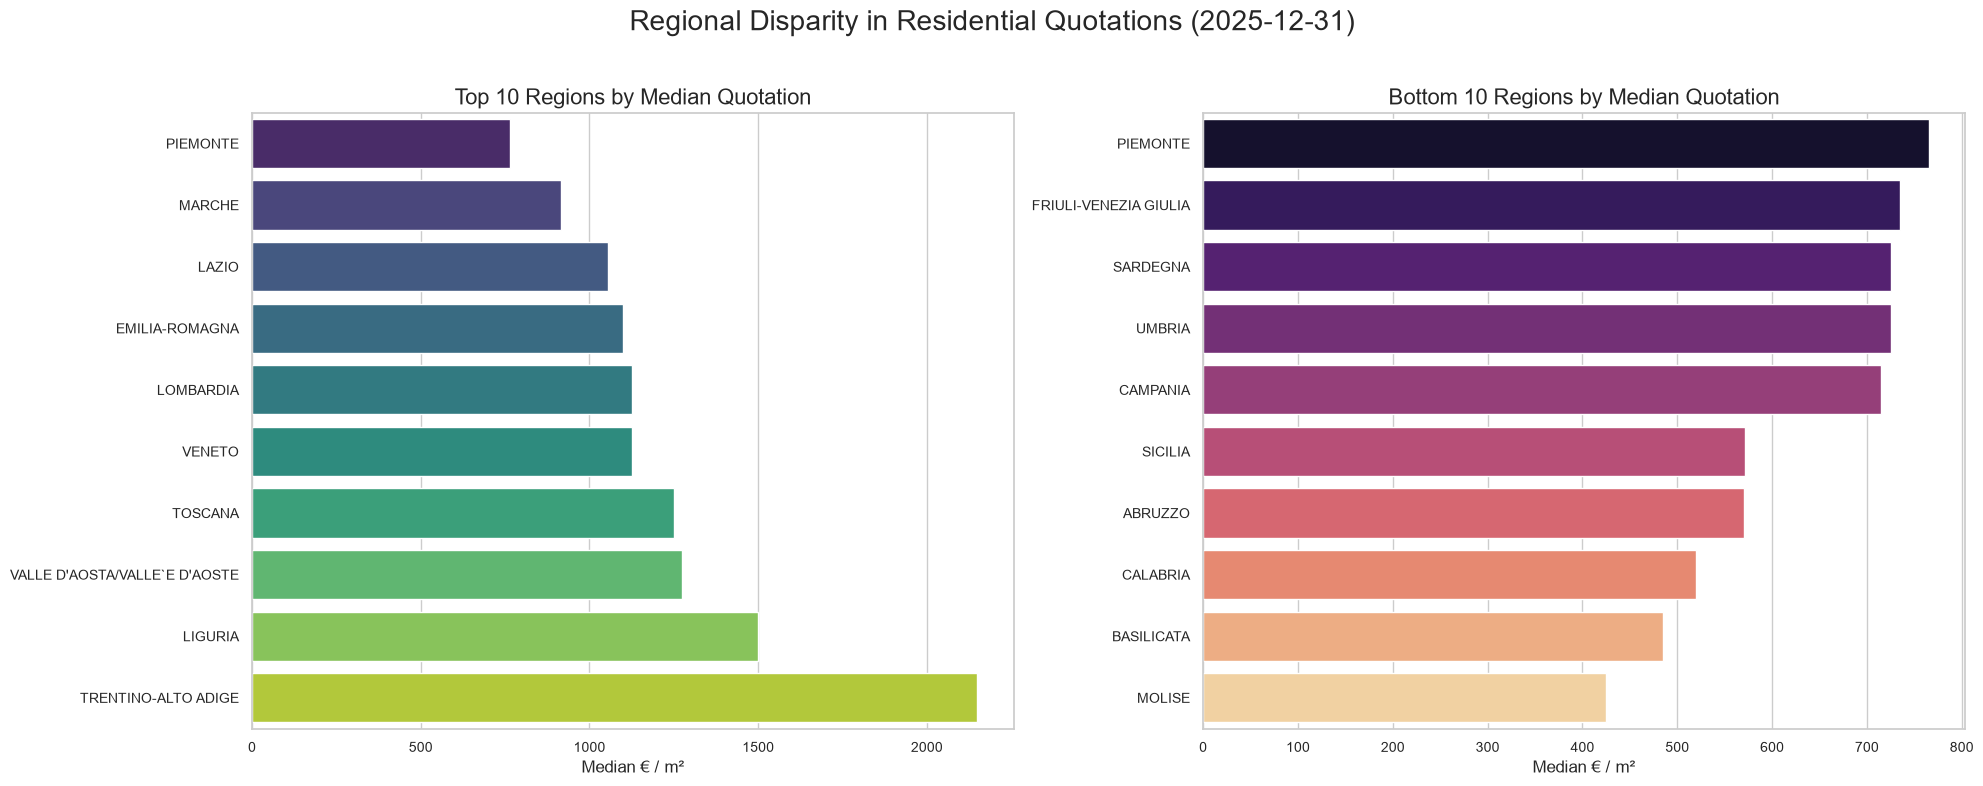

In [13]:
# Cell 12: Top and Bottom 10 Regions
top_regions_latest = (
    regional_trend[regional_trend['reference_date'] == latest_date]
    .nlargest(10, 'median_compr_mid')
)
bottom_regions_latest = (
    regional_trend[regional_trend['reference_date'] == latest_date]
    .nsmallest(10, 'median_compr_mid')
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(y='Regione', x='median_compr_mid', data=top_regions_latest.sort_values('median_compr_mid'), ax=ax1, palette='viridis')
ax1.set_title('Top 10 Regions by Median Quotation')
ax1.set_xlabel('Median € / m²')
ax1.set_ylabel('')

sns.barplot(y='Regione', x='median_compr_mid', data=bottom_regions_latest.sort_values('median_compr_mid', ascending=False), ax=ax2, palette='magma')
ax2.set_title('Bottom 10 Regions by Median Quotation')
ax2.set_xlabel('Median € / m²')
ax2.set_ylabel('')

plt.suptitle(f'Regional Disparity in Residential Quotations ({latest_date.date()})', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

> **Insight:** There is a vast disparity in real estate values across Italy. The top regions (e.g., Trentino-Alto Adige, Valle d'Aosta, Tuscany, Lazio) are predominantly in the north and center, often featuring prestigious tourist destinations or major economic hubs. In contrast, the bottom regions are concentrated in the south (e.g., Molise, Sicily, Calabria), with median prices that can be up to 3-4 times lower. This confirms that "the Italian market" is a mosaic of highly distinct sub-markets.

## 7. Provincial Market Analysis

We drill down to the provincial level. To ensure robust rankings, we filter provinces to include only those with a minimum number of observations (`MIN_OBSERVATIONS_FOR_RANKING`) in the latest semester.

C:\Users\cc1323\AppData\Local\Temp\ipykernel_22124\4182871480.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Prov', x='median_compr_mid', data=top_provinces_latest.sort_values('median_compr_mid'), ax=ax, palette='viridis')


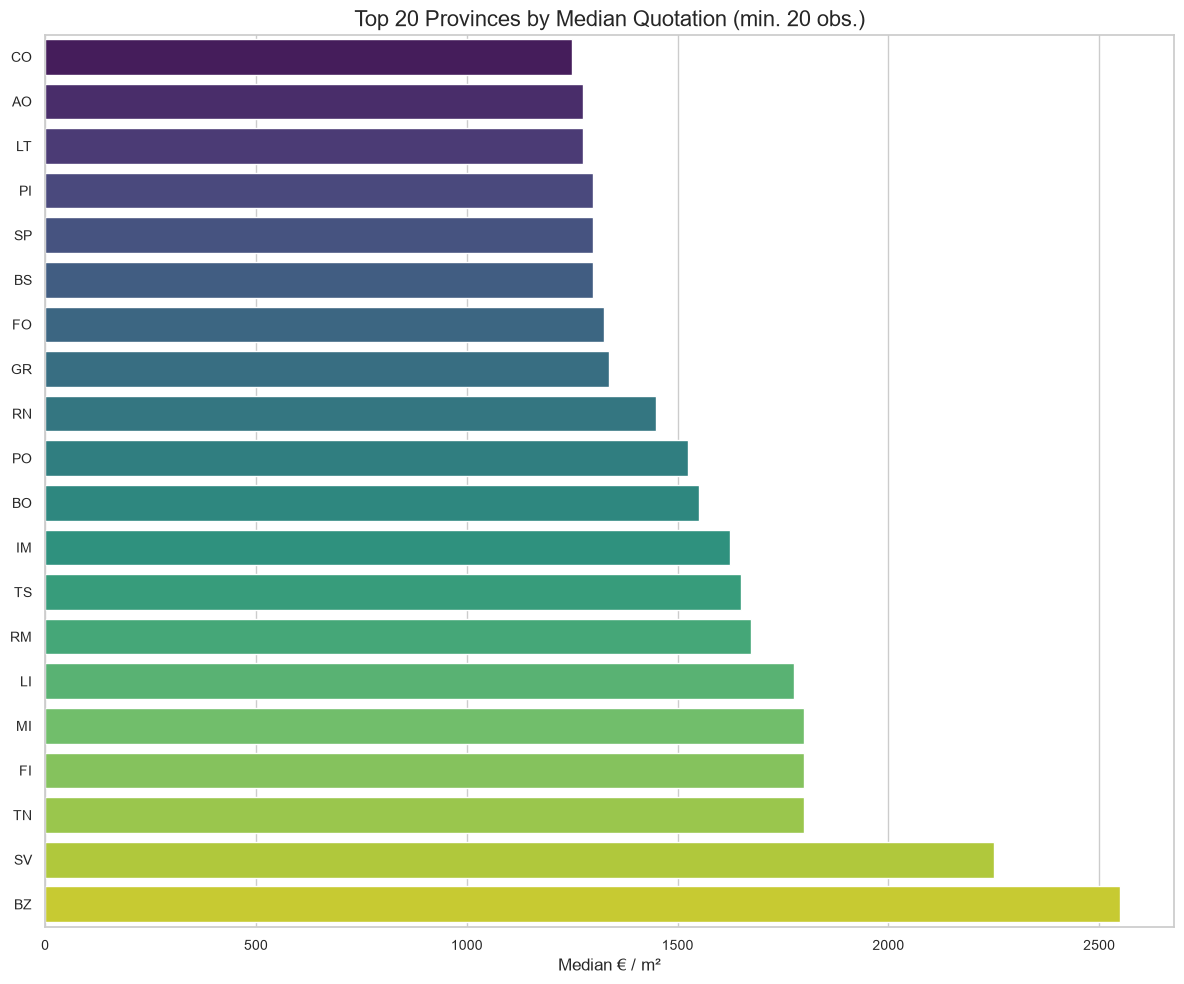

In [14]:
# Cell 13: Provincial Analysis (with minimum observation filter)
provincial_trend = (
    residential
    .groupby(['reference_date', 'Prov'], as_index=False)
    .agg(median_compr_mid=('Compr_mid', 'median'))
)
latest_date = provincial_trend['reference_date'].max()
latest_prov_data = provincial_trend[provincial_trend['reference_date'] == latest_date]

# Apply minimum observation filter for robustness
observations_by_prov = residential[residential['reference_date'] == latest_date]['Prov'].value_counts()
valid_provs = observations_by_prov[observations_by_prov >= MIN_OBSERVATIONS_FOR_RANKING].index

top_provinces_latest = (
    latest_prov_data[latest_prov_data['Prov'].isin(valid_provs)]
    .nlargest(20, 'median_compr_mid')
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.barplot(y='Prov', x='median_compr_mid', data=top_provinces_latest.sort_values('median_compr_mid'), ax=ax, palette='viridis')
ax.set_title(f'Top 20 Provinces by Median Quotation (min. {MIN_OBSERVATIONS_FOR_RANKING} obs.)')
ax.set_xlabel('Median € / m²')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

> **Insight:** At the provincial level, the list is topped by provinces with major metropolitan centers or high-end tourist locations (e.g., Venice, Milan, Bolzano, Rome, Florence). The minimum observation filter ensures that these rankings are not skewed by small, volatile markets.

### 7.1 Provincial Trend Comparison

To compare performance across provinces over time, we plot the cumulative percentage change from a baseline period (e.g., 2010). This normalizes the data and allows for a direct comparison of growth trajectories, regardless of the initial price level.

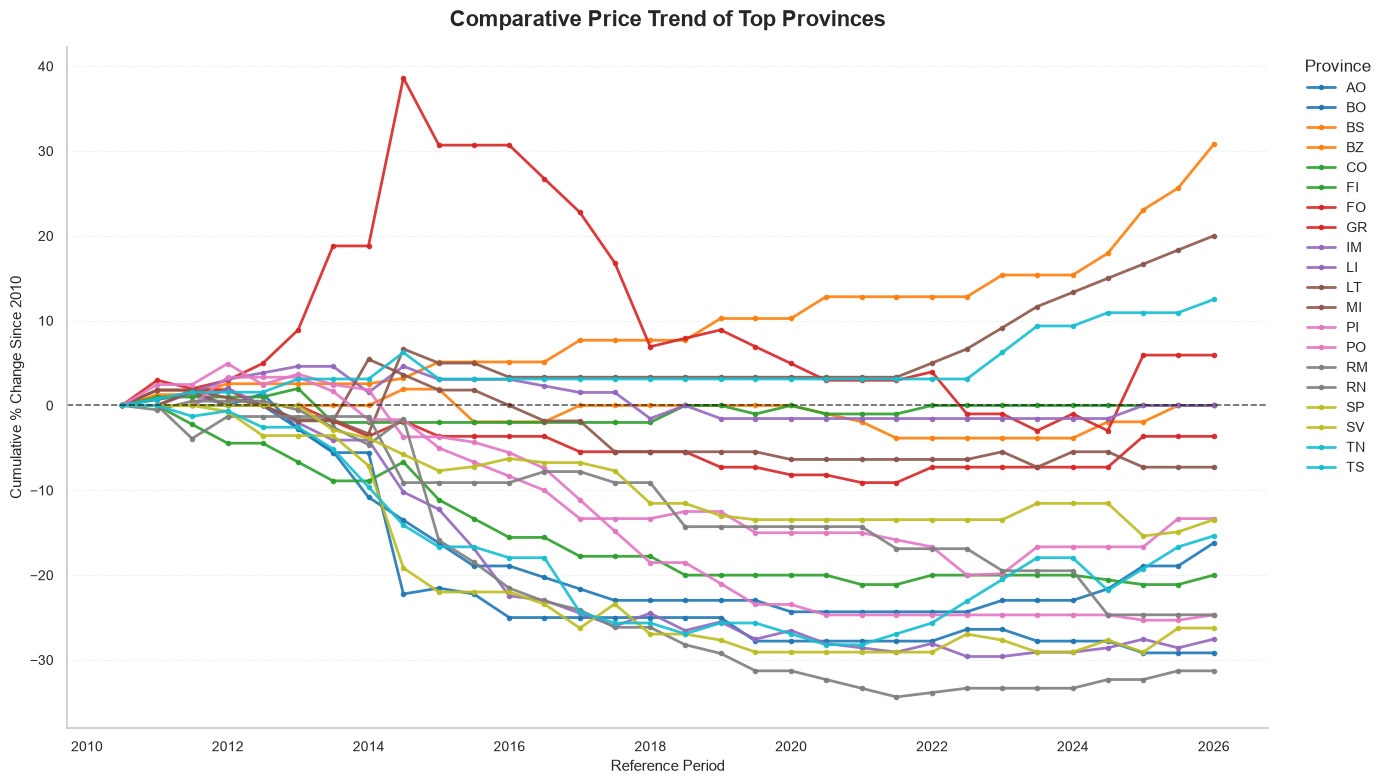

In [15]:
# Cell 14: Provincial Trend Comparison (% change from a baseline)

top_prov_names = top_provinces_latest['Prov'].tolist()

# Filter for top provinces and a reasonable time range
plot_data = provincial_trend[
    provincial_trend['Prov'].isin(top_prov_names)
].copy()

plot_data = plot_data[
    plot_data['reference_date'] >= '2010-01-01'
]

# Pivot to get provinces as columns
pivot_data = plot_data.pivot(
    index='reference_date',
    columns='Prov',
    values='median_compr_mid'
)

# Normalize to the first observation in the period
normalized_data = (
    pivot_data.div(pivot_data.iloc[0]) - 1
) * 100


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8))

# Professional categorical palette
colors = plt.cm.tab10(
    np.linspace(0, 1, len(normalized_data.columns))
)

for prov, color in zip(normalized_data.columns, colors):

    ax.plot(
        normalized_data.index,
        normalized_data[prov],
        label=prov,
        color=color,
        marker='o',
        markersize=3,
        linewidth=2,
        alpha=0.9
    )


# Baseline
ax.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    alpha=0.6
)


# Titles and labels
ax.set_title(
    'Comparative Price Trend of Top Provinces',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Reference Period',
    fontsize=11
)

ax.set_ylabel(
    'Cumulative % Change Since 2010',
    fontsize=11
)


# Grid
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.7,
    alpha=0.25
)

ax.grid(
    axis='x',
    visible=False
)


# Legend
ax.legend(
    title='Province',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)


# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Improve layout
plt.tight_layout()
plt.show()

> **Insight:** This chart allows for a true performance comparison. While some provinces like Venice and Milan show strong and consistent growth, others have experienced periods of stagnation or even decline. The post-2015 period shows a general recovery across most premium markets, with some (e.g., Bolzano, Milan) significantly outpacing others. This type of analysis is crucial for understanding relative market dynamics.

## 8. Municipal & Sub-Municipal Analysis

We further drill down to the municipal level. This granularity is essential for identifying specific high-value locations that may be hidden within a province's aggregate statistics. As with provinces, we apply a minimum observation filter.

C:\Users\cc1323\AppData\Local\Temp\ipykernel_20368\775900241.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Comune_descrizione', x='median_compr_mid', data=top_municipalities_latest.sort_values('median_compr_mid'), ax=ax, palette='viridis')


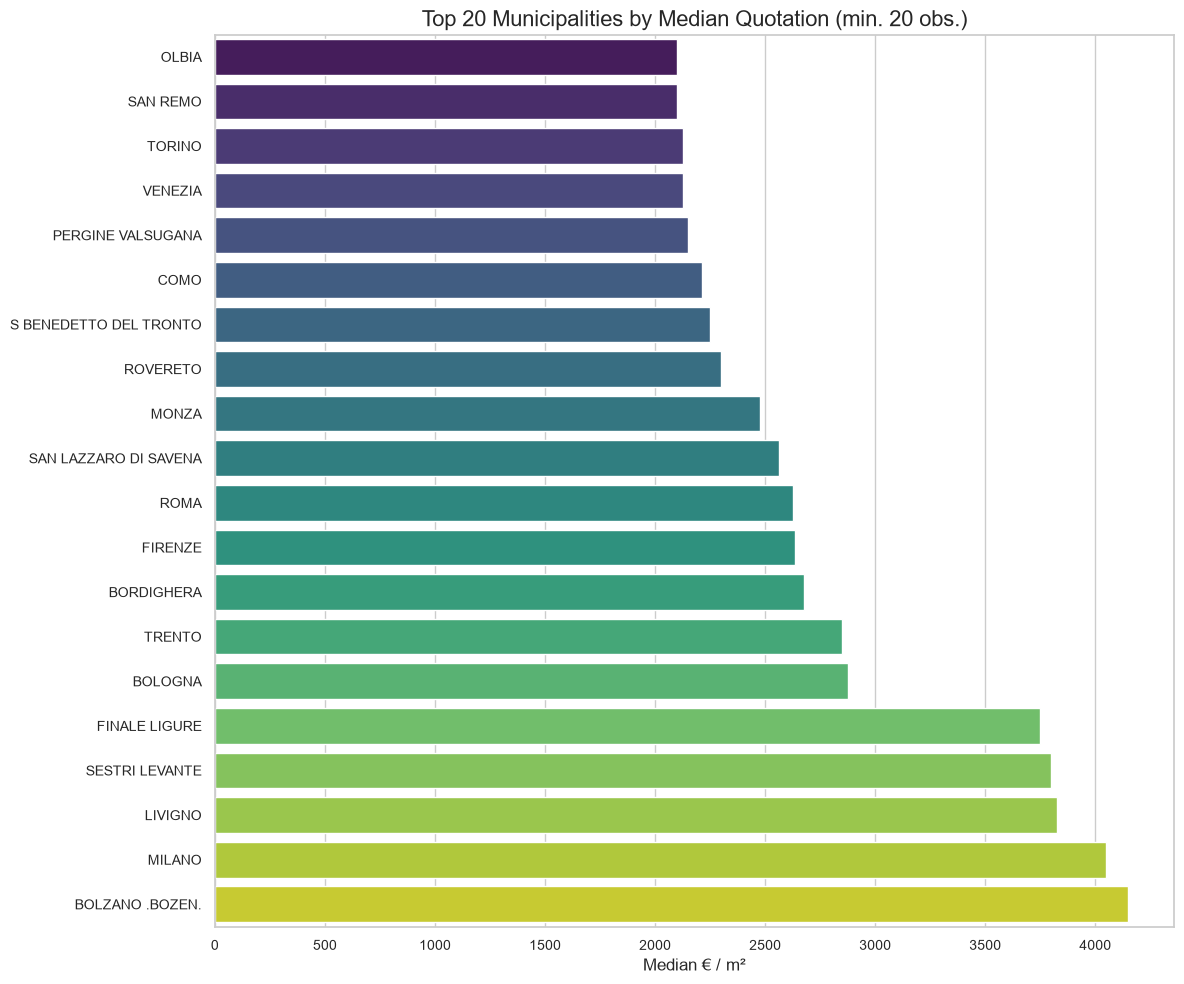

In [15]:
# Cell 15: Municipal Analysis (with filter)
municipal_trend = (
    residential
    .groupby(['reference_date', 'Comune_descrizione'], as_index=False)
    .agg(median_compr_mid=('Compr_mid', 'median'))
)
latest_date = municipal_trend['reference_date'].max()
latest_mun_data = municipal_trend[municipal_trend['reference_date'] == latest_date]

# Apply minimum observation filter
observations_by_mun = residential[residential['reference_date'] == latest_date]['Comune_descrizione'].value_counts()
valid_muns = observations_by_mun[observations_by_mun >= MIN_OBSERVATIONS_FOR_RANKING].index

top_municipalities_latest = (
    latest_mun_data[latest_mun_data['Comune_descrizione'].isin(valid_muns)]
    .nlargest(20, 'median_compr_mid')
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.barplot(y='Comune_descrizione', x='median_compr_mid', data=top_municipalities_latest.sort_values('median_compr_mid'), ax=ax, palette='viridis')
ax.set_title(f'Top 20 Municipalities by Median Quotation (min. {MIN_OBSERVATIONS_FOR_RANKING} obs.)')
ax.set_xlabel('Median € / m²')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

> **Insight:** The municipal ranking is dominated by exclusive locations: renowned seaside resorts (e.g., Portofino, Capri), prestigious historical centers (e.g., Venice, Florence, Rome), and luxury mountain destinations (e.g., Cortina d'Ampezzo). This level of granularity is critical for investment decisions, as it reveals the true top-tier markets.

## 9. Regional Deep Dive: Lombardy & Brescia

As a focused case study, we zoom in on the Lombardy region and the Province of Brescia. This demonstrates the analytical framework's ability to provide actionable insights for specific, localized markets.

C:\Users\cc1323\AppData\Local\Temp\ipykernel_20368\1767356399.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Comune_descrizione', x='median_compr_mid', data=top_brescia_muns.sort_values('median_compr_mid'), ax=ax, palette='viridis')


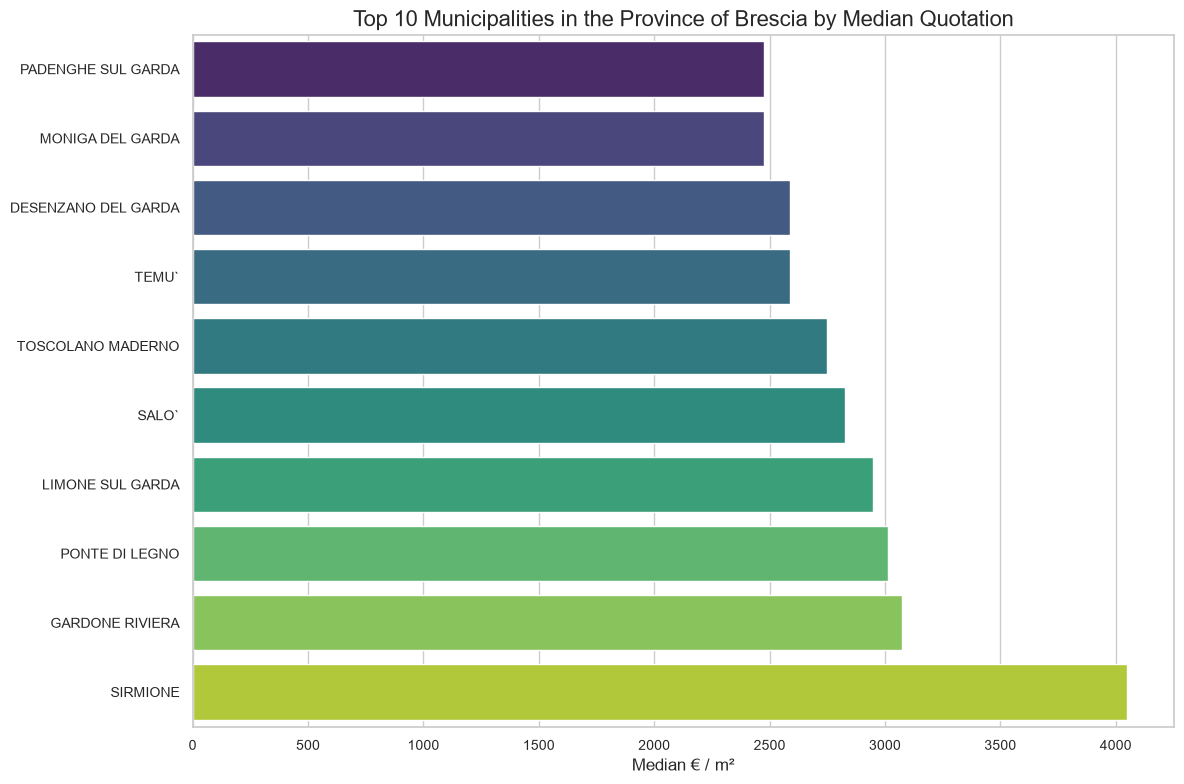

In [16]:
# Cell 16: Lombardy & Brescia Analysis
# Filter for Lombardy
lombardy_data = residential[residential['Regione'] == 'LOMBARDIA'].copy()

# Filter for Brescia province
brescia_data = lombardy_data[lombardy_data['Prov'] == 'BS'].copy()

# Analyze municipal trends within Brescia
brescia_municipal_trend = (
    brescia_data
    .groupby(['reference_date', 'Comune_descrizione'], as_index=False)
    .agg(median_compr_mid=('Compr_mid', 'median'))
)
latest_date = brescia_municipal_trend['reference_date'].max()
latest_brescia_data = brescia_municipal_trend[brescia_municipal_trend['reference_date'] == latest_date]

# Top municipalities in Brescia
top_brescia_muns = latest_brescia_data.nlargest(10, 'median_compr_mid')

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(y='Comune_descrizione', x='median_compr_mid', data=top_brescia_muns.sort_values('median_compr_mid'), ax=ax, palette='viridis')
ax.set_title('Top 10 Municipalities in the Province of Brescia by Median Quotation')
ax.set_xlabel('Median € / m²')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

> **Insight:** Within the Province of Brescia, the highest quotations are found in municipalities along Lake Garda (e.g., Sirmione, Desenzano del Garda, Toscolano-Maderno) and the city of Brescia itself. This intra-provincial analysis reveals significant local disparities that are masked by the provincial median.

## 10. Growth & Risk Analytics

To provide a forward-looking perspective, we compute key growth and risk metrics for each region. We restrict the analysis to series with sufficient history (`MIN_PERIODS_FOR_GROWTH`) to ensure statistical relevance.

- **CAGR (Compound Annual Growth Rate):** Measures the smoothed annual growth rate over the entire period.
- **Annualized Volatility:** The standard deviation of YoY growth rates, serving as a proxy for market risk.
- **Max Drawdown:** The largest peak-to-trough decline in median prices, indicating downside risk.

In [17]:
# Cell 17: Calculate growth and risk metrics for regions
MIN_PERIODS = MIN_PERIODS_FOR_GROWTH

# Calculate YoY growth rates per region
regional_yoy = regional_trend.sort_values(['Regione', 'reference_date']).copy()
regional_yoy['yoy_growth'] = regional_yoy.groupby('Regione')['median_compr_mid'].pct_change(periods=2) # 2 semesters = 1 year

# Aggregate metrics
risk_metrics = regional_yoy.groupby('Regione').apply(
    lambda df: pd.Series({
        'num_periods': len(df),
        'cagr': (df['median_compr_mid'].iloc[-1] / df['median_compr_mid'].iloc[0])**(1 / ((len(df)-1)/2)) - 1 if len(df) > 1 else np.nan,
        'volatility': df['yoy_growth'].std() * np.sqrt(1), # Annualized from YoY
        'max_drawdown': (df['median_compr_mid'] / df['median_compr_mid'].cummax() - 1).min()
    }),
    include_groups=False
).reset_index()

# Filter for regions with sufficient data
risk_metrics = risk_metrics[risk_metrics['num_periods'] >= MIN_PERIODS]

print(f"Growth and Risk Metrics by Region (min. {MIN_PERIODS} periods of data):")
display(risk_metrics.sort_values('cagr', ascending=False).style.format({
    'cagr': '{:.2%}',
    'volatility': '{:.2%}',
    'max_drawdown': '{:.2%}'
}).background_gradient(cmap='RdYlGn', subset=['cagr']))

Growth and Risk Metrics by Region (min. 8 periods of data):


,Regione,num_periods,cagr,volatility,max_drawdown
12,PUGLIA,44.000000,1.59%,5.73%,-14.71%
6,LAZIO,44.000000,1.44%,7.86%,-24.64%
16,TRENTINO-ALTO ADIGE,44.000000,1.24%,1.55%,-2.63%
13,SARDEGNA,44.000000,1.13%,3.52%,-6.67%
2,CALABRIA,44.000000,1.05%,3.11%,-8.93%
19,VENETO,44.000000,0.98%,3.78%,-10.20%
1,BASILICATA,44.000000,0.76%,3.38%,-9.35%
7,LIGURIA,44.000000,0.61%,3.70%,-17.14%
14,SICILIA,44.000000,0.44%,3.18%,-18.39%
9,MARCHE,44.000000,0.37%,3.34%,-18.35%


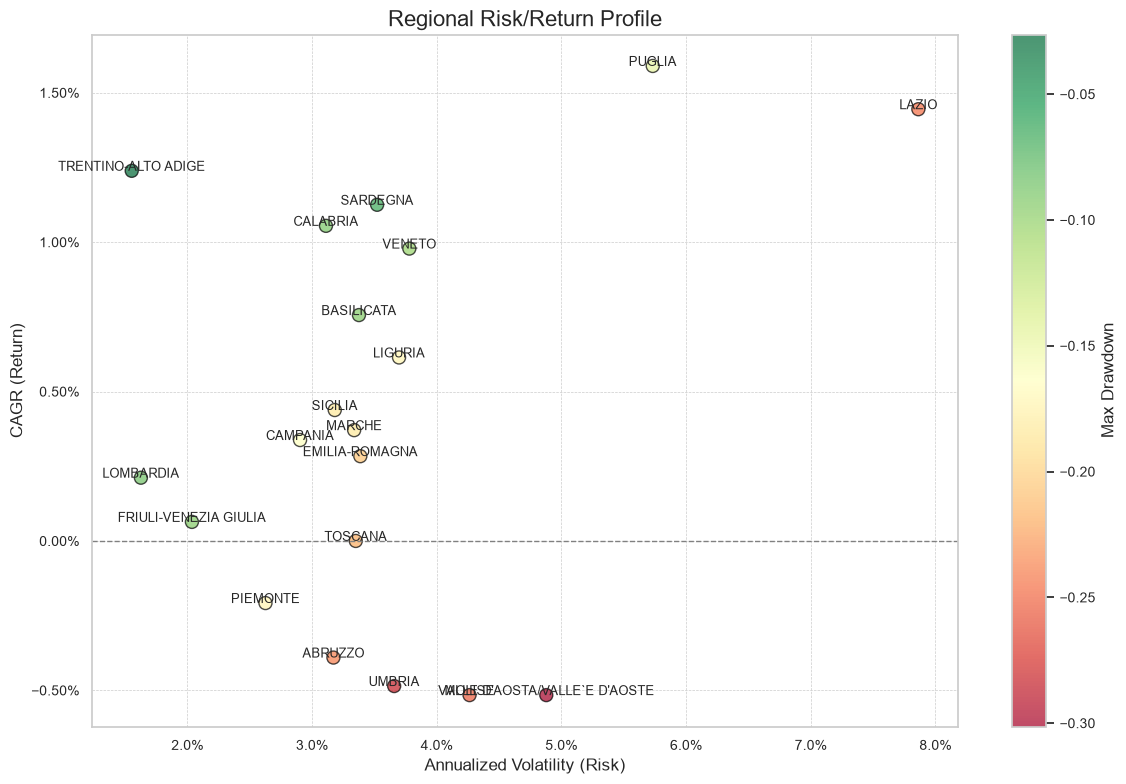

In [18]:
# Cell 18: Visualize Risk/Return profile
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    risk_metrics['volatility'],
    risk_metrics['cagr'],
    s=risk_metrics['num_periods'] * 2, # Size by number of periods (proxy for data reliability)
    c=risk_metrics['max_drawdown'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='k'
)

for i, txt in enumerate(risk_metrics['Regione']):
    ax.annotate(txt, (risk_metrics['volatility'].iloc[i], risk_metrics['cagr'].iloc[i]), fontsize=9, ha='center')

ax.set_title('Regional Risk/Return Profile')
ax.set_xlabel('Annualized Volatility (Risk)')
ax.set_ylabel('CAGR (Return)')
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
fig.colorbar(scatter, label='Max Drawdown')
plt.tight_layout()
plt.show()

> **Insight:** This risk/return scatter plot is a powerful tool for investors. Regions in the top-left quadrant offer the best risk-adjusted returns (high growth, low volatility). Conversely, regions in the bottom-right are the most volatile with the lowest returns. The color (Max Drawdown) adds another layer, highlighting regions that have experienced significant historical price declines. This analysis provides a quantitative basis for regional investment strategies.

---

## Conclusion

This notebook has provided a comprehensive analysis of the OMI residential real estate quotations, revealing significant insights at every geographical level.

**Key Findings:**
- The national market is highly skewed, with the median price being a more representative indicator than the mean.
- There is substantial regional disparity, with northern and central regions commanding significantly higher prices than southern regions.
- Provincial and municipal analysis reveals that premium markets are concentrated in major metropolitan areas and exclusive tourist destinations.
- The Risk/Return analysis provides a quantitative framework for comparing regional investment opportunities.

**Next Steps:**
- Integrate macroeconomic indicators (e.g., GDP, unemployment, interest rates) to build predictive models.
- Analyze the relationship between OMI quotations and actual transaction prices.
- Extend the analysis to commercial and industrial property types.